## **TITANIC Dataset Analysis using Pandas**

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**PROJECT INTRODUCTION**:

This project demonstrates how to perform data cleaning and preprocessing on the Titanic dataset using Python. The dataset contains passenger details such as age, gender, ticket fare, passenger class, cabin information, and survival status.

The objective is to transform raw data into a clean and structured format by handling missing values, removing unnecessary data, and performing feature engineering. This cleaned dataset can later be used for visualization and machine learning.


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## **Import libraries**
Import the required libraries for data loading, cleaning, and visualization.

**PANDAS**  -> Used for reading, cleaning, and manipulating the dataset. 
- This helps in converting raw data into structured manner.
- To extract the data from csv and clean the data

**Matplotlib**  -> Used for creating basic data visualizations.

**Seaborn** ->Used for statistical plots and identifying data patterns.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## **Load Dataset**
Read the Titanic CSV file into a Pandas DataFrame(Table format).

In [3]:
df=pd.read_csv("titanic.csv")
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0



**Display the first few rows of the dataset.**

In [4]:
df.head(10)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
5,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,1
6,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,1
7,1,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,0
8,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,1
9,1,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,0


**Display the last few rows of the dataset.**

In [5]:
df.tail()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
1304,3,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,0
1308,3,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,0



## **Check Duplicate Records**

Duplicate records can affect data analysis.

This step checks whether the dataset contains any repeated rows.

In [6]:
df.duplicated() ## Checks every row and tells whether it is a duplicate

0       False
1       False
2       False
3       False
4       False
        ...  
1304    False
1305    False
1306    False
1307    False
1308    False
Length: 1309, dtype: bool

In [7]:
df.duplicated().any()   ## Checks whether any duplicate records exist in the entire dataset


False

In [8]:
# it gives the summary of the records
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


**Column Description**

- pclass-----passenger class
- sibsp------sibling /spouse
- parch -----parents and children
- fare--------ammount
- embarked-----boarding point(starting journey place)


## **Handling Missing Values**

Real-world datasets often contain missing values.
These missing values should be handled before analysis to improve data quality.

- There are two ways of filling missing values

-> numerical columns--- mean()

-> categorical columns---mode()

    ** Embarked, Fare, Cabin columns are having null values

**Age col:**

In [9]:
age_mean=df['age'].mean()
age_mean

29.8811345124283

**Fare col:**

In [10]:
fare_mean=df['fare'].mean()
fare_mean

33.29547928134557

**Embarked col:**

the **Embarked** col is categorical.



In [11]:
df['embarked'].unique() # Unique displays all different values present in the embarked column.
## This helps to understand the available categories before filling misiing values.

array(['S', 'C', nan, 'Q'], dtype=object)

We calculate Mode(most frequently occuring value) and use it to replace the missing values

In [12]:
embarked_mode=df['embarked'].mode()[0] # 0 bcz first most repeated value
embarked_mode

'S'

## **Fill Missing values**

After calculating the mean and mode, we replace  the missing valuesusing **fillna()** functions

after finding the null values , we have to fill the null values

In [13]:
df['age']=df['age'].fillna(age_mean)
df['fare']=df['fare'].fillna(fare_mean)
df['embarked']=df['embarked'].fillna(embarked_mode)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1309 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


## Remove Unnecessary Columns

**cabin col:**

- By, looking into cabin column, there are many missing values, Therfore, drop the column

- Some columns contain too many missing values or are not useful for our analysis.

- Removing them makes the dataset cleaner and easier to work with.

In [15]:
## dropna : it is used to drop the clumns
# we will drop cabin column
# we have  parametr axis, 
                #xais(row)=0
                #yaxis(clumn}=1
## ✔️to delete the cloumnn ->>>>>> axis=1------- it checks row by row
## ✔️to delete the row(records) ->>>>>> axis=0------ it checks column by column


df=df.dropna(axis=1)
df


,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.916700,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,151.5500,S,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,14.4542,C,0
1305,3,"Zabour, Miss. Thamine",female,29.881135,1,0,2665,14.4542,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,7.2250,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,7.2250,C,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   object 
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 102.4+ KB


In [17]:
## check each column has null values
df['pclass'].unique()

array([1, 2, 3], dtype=int64)

## **Create New Features**

- The Name column contains multiple pieces of information.

- We split it into separate columns such as Last Name, First Name, and Title to make the data more organized.

- In the name column, last names are mixed , do it  to  proper  order

In [18]:
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.916700,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,151.5500,S,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,14.4542,C,0
1305,3,"Zabour, Miss. Thamine",female,29.881135,1,0,2665,14.4542,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,7.2250,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,7.2250,C,0


In [19]:
df['name'].str.split(',',expand=True)   # expand creates the table

,0,1
0,Allen,Miss. Elisabeth Walton
1,Allison,Master. Hudson Trevor
2,Allison,Miss. Helen Loraine
3,Allison,Mr. Hudson Joshua Creighton
4,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)
...,...,...
1304,Zabour,Miss. Hileni
1305,Zabour,Miss. Thamine
1306,Zakarian,Mr. Mapriededer
1307,Zakarian,Mr. Ortin


## **Feature Engineering(Create New Features)** 


The Name column contains multiple pieces of information.

We split it into separate columns such as Last Name, First Name, and Title to make the data more organized.

- let us rename column 0  to last name, and 1 to the fiirst name
- we are going to name two columns Hence,2 [[]] braces are given

## [1] **Create and split Name column**

In [20]:
df[['L_name','F_name']]=df['name'].str.split(',',expand=True)
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,1,Allen,Miss. Elisabeth Walton
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,1,Allison,Master. Hudson Trevor
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,0,Allison,Miss. Helen Loraine
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,0,Allison,Mr. Hudson Joshua Creighton
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,0,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)


 **Drop the name column**

In [21]:
df=df.drop(columns='name')
df


,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name
0,1,female,29.000000,0,0,24160,211.3375,S,1,Allen,Miss. Elisabeth Walton
1,1,male,0.916700,1,2,113781,151.5500,S,1,Allison,Master. Hudson Trevor
2,1,female,2.000000,1,2,113781,151.5500,S,0,Allison,Miss. Helen Loraine
3,1,male,30.000000,1,2,113781,151.5500,S,0,Allison,Mr. Hudson Joshua Creighton
4,1,female,25.000000,1,2,113781,151.5500,S,0,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.500000,1,0,2665,14.4542,C,0,Zabour,Miss. Hileni
1305,3,female,29.881135,1,0,2665,14.4542,C,0,Zabour,Miss. Thamine
1306,3,male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mr. Mapriededer
1307,3,male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Mr. Ortin


**Split the F_name column**

In [22]:
## while creating the table, if the table creates extra none column , so give n=1
df[['title','F_name']]=df['F_name'].str.split('.',expand=True,n=1)
df

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name,title
0,1,female,29.000000,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,male,0.916700,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,female,2.000000,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,male,30.000000,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,female,25.000000,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.500000,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,female,29.881135,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


**Removing the spaces**

after splitingthe text, cleaning the columns

In [23]:
## to remove the spaces
df['title']=df['title'].str.strip()
df['F_name']=df['F_name'].str.strip()
df['title']
df['F_name']

0                        Elisabeth Walton
1                           Hudson Trevor
2                           Helen Loraine
3                 Hudson Joshua Creighton
4       Hudson J C (Bessie Waldo Daniels)
                      ...                
1304                               Hileni
1305                              Thamine
1306                          Mapriededer
1307                                Ortin
1308                                  Leo
Name: F_name, Length: 1309, dtype: object

In [24]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name,title
0,1,female,29.000000,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,male,0.916700,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,female,2.000000,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,male,30.000000,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,female,25.000000,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.500000,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,female,29.881135,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


## **Rename the column**(sex-> gender)

In [25]:
# changing the clumn name

df=df.rename(columns={'sex':'Gender'})
df

,pclass,Gender,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name,title
0,1,female,29.000000,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,male,0.916700,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,female,2.000000,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,male,30.000000,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,female,25.000000,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.500000,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,female,29.881135,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


## **Checking Data Inconsistencies**

  **(i)  Standardize Name Format**

The names in the dataset may have inconsistent letter casing.

We convert them to title case so that each word starts with a capital letter, making the data clean and consistent. 

In [26]:
df['Gender']=df['Gender'].str.capitalize()
df

,pclass,Gender,age,sibsp,parch,ticket,fare,embarked,survived,L_name,F_name,title
0,1,Female,29.000000,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,Male,0.916700,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,Female,2.000000,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,Male,30.000000,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,Female,25.000000,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.500000,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,Female,29.881135,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,Male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,Male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


**(ii)  to capitalize each column name**

In [27]:


df.columns=df.columns.str.capitalize()
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title
0,1,Female,29.000000,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,Male,0.916700,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,Female,2.000000,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,Male,30.000000,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,Female,25.000000,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.500000,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,Female,29.881135,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,Male,26.500000,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,Male,27.000000,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


**(iii) Round off thebage values**

In [28]:

df['Age']=df['Age'].round(1)
df

,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title
0,1,Female,29.0,0,0,24160,211.3375,S,1,Allen,Elisabeth Walton,Miss
1,1,Male,0.9,1,2,113781,151.5500,S,1,Allison,Hudson Trevor,Master
2,1,Female,2.0,1,2,113781,151.5500,S,0,Allison,Helen Loraine,Miss
3,1,Male,30.0,1,2,113781,151.5500,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,Female,25.0,1,2,113781,151.5500,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5,1,0,2665,14.4542,C,0,Zabour,Hileni,Miss
1305,3,Female,29.9,1,0,2665,14.4542,C,0,Zabour,Thamine,Miss
1306,3,Male,26.5,0,0,2656,7.2250,C,0,Zakarian,Mapriededer,Mr
1307,3,Male,27.0,0,0,2670,7.2250,C,0,Zakarian,Ortin,Mr


**(iv)   round the number to single digit**

In [29]:
## 
df['Fare']=df['Fare'].round(1)

df

,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title
0,1,Female,29.0,0,0,24160,211.3,S,1,Allen,Elisabeth Walton,Miss
1,1,Male,0.9,1,2,113781,151.6,S,1,Allison,Hudson Trevor,Master
2,1,Female,2.0,1,2,113781,151.6,S,0,Allison,Helen Loraine,Miss
3,1,Male,30.0,1,2,113781,151.6,S,0,Allison,Hudson Joshua Creighton,Mr
4,1,Female,25.0,1,2,113781,151.6,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5,1,0,2665,14.5,C,0,Zabour,Hileni,Miss
1305,3,Female,29.9,1,0,2665,14.5,C,0,Zabour,Thamine,Miss
1306,3,Male,26.5,0,0,2656,7.2,C,0,Zakarian,Mapriededer,Mr
1307,3,Male,27.0,0,0,2670,7.2,C,0,Zakarian,Ortin,Mr


## [2] **Create Fam_count**


The dataset contains two columns: `SibSp` and `Parch`, which represent different family members traveling with a passenger.

We combine these columns to create a new feature called **Fam_count**. This represents the total number of family members traveling with each passenger and makes it easier to analyze the effect of family size on passenger survival.

In [30]:
## sibling , spouse, parent and chid are from same fam,lets use count

df['Fam_count']=df['Sibsp']+df['Parch']
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count
0,1,Female,29.0,0,0,24160,211.3,S,1,Allen,Elisabeth Walton,Miss,0
1,1,Male,0.9,1,2,113781,151.6,S,1,Allison,Hudson Trevor,Master,3
2,1,Female,2.0,1,2,113781,151.6,S,0,Allison,Helen Loraine,Miss,3
3,1,Male,30.0,1,2,113781,151.6,S,0,Allison,Hudson Joshua Creighton,Mr,3
4,1,Female,25.0,1,2,113781,151.6,S,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5,1,0,2665,14.5,C,0,Zabour,Hileni,Miss,1
1305,3,Female,29.9,1,0,2665,14.5,C,0,Zabour,Thamine,Miss,1
1306,3,Male,26.5,0,0,2656,7.2,C,0,Zakarian,Mapriededer,Mr,0
1307,3,Male,27.0,0,0,2670,7.2,C,0,Zakarian,Ortin,Mr,0


## **Data Transformation**

**(i)  Replace Abbreviations**

The `Embarked` column contains short codes (`S`, `C`, and `Q`).

We replace these codes with their full names to make the dataset easier to understand.

In [31]:

df['Embarked'].unique()
## we need to write the full name
# S=Southampton
# C=Cherbourge
# Q=Queenstown
## to replace the values let us use the dict

array(['S', 'C', 'Q'], dtype=object)

In [32]:
d={'S':'Southampton','C':'Cherbourge','Q':'Queenstown'}
df['Embarked']=df['Embarked'].replace(d)
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count
0,1,Female,29.0,0,0,24160,211.3,Southampton,1,Allen,Elisabeth Walton,Miss,0
1,1,Male,0.9,1,2,113781,151.6,Southampton,1,Allison,Hudson Trevor,Master,3
2,1,Female,2.0,1,2,113781,151.6,Southampton,0,Allison,Helen Loraine,Miss,3
3,1,Male,30.0,1,2,113781,151.6,Southampton,0,Allison,Hudson Joshua Creighton,Mr,3
4,1,Female,25.0,1,2,113781,151.6,Southampton,0,Allison,Hudson J C (Bessie Waldo Daniels),Mrs,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5,1,0,2665,14.5,Cherbourge,0,Zabour,Hileni,Miss,1
1305,3,Female,29.9,1,0,2665,14.5,Cherbourge,0,Zabour,Thamine,Miss,1
1306,3,Male,26.5,0,0,2656,7.2,Cherbourge,0,Zakarian,Mapriededer,Mr,0
1307,3,Male,27.0,0,0,2670,7.2,Cherbourge,0,Zakarian,Ortin,Mr,0


## **Sort the Dataset**

As we can see some passengers are having same ticket, same fare 

- The `sort_values()` function is used to arrange the rows in a meaningful order based on one or more columns.

- In this project, the dataset is sorted by **Ticket**, **Age**, and **Fare**. Sorting makes it easier to identify passengers with the same ticket number and compare related records.

- This step does not remove or select any records; it only changes their order.

In [33]:
## sort_values is to arrange the records, on what we pass
## by default there is ascennding
df=df.sort_values(by=['Ticket','Age','Fare'],ascending=[True,True,True])
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count
195,1,Female,16.0,0,0,110152,86.5,Southampton,1,Maioni,Roberta,Miss,0
67,1,Female,30.0,0,0,110152,86.5,Southampton,1,Cherry,Gladys,Miss,0
245,1,Female,33.0,0,0,110152,86.5,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0
289,1,Female,18.0,0,2,110413,79.6,Southampton,1,Taussig,Ruth,Miss,2
291,1,Female,39.0,1,1,110413,79.6,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,Chaffee,Herbert Fuller,Mr,1
63,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1
433,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0
82,1,Female,36.0,0,2,WE/P 5735,71.0,Southampton,1,Crosby,Harriet R,Miss,2


**Reset the index**

In [34]:

df=df.reset_index(drop=True)
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count
0,1,Female,16.0,0,0,110152,86.5,Southampton,1,Maioni,Roberta,Miss,0
1,1,Female,30.0,0,0,110152,86.5,Southampton,1,Cherry,Gladys,Miss,0
2,1,Female,33.0,0,0,110152,86.5,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,Taussig,Ruth,Miss,2
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,Chaffee,Herbert Fuller,Mr,1
1305,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0
1307,1,Female,36.0,0,2,WE/P 5735,71.0,Southampton,1,Crosby,Harriet R,Miss,2


## **Analyze Ticket Distribution**

**Count Passengers by Ticket Number**

Some passengers share the same ticket because they were traveling together.

- We use `value_counts()` to count the number of passengers associated with each ticket. 

- The `reset_index()` function converts the result into a DataFrame for easier analysis.

In [35]:

df['Ticket'].value_counts().reset_index() ## it gives the frequency 

,Ticket,count
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,342826,1
925,343095,1
926,343120,1
927,343271,1


**(i)  Rename the count column to No_of_passengers**

In [36]:

## it creates separate table (Dataframe) for ticket
Ticket_pass=df['Ticket'].value_counts().reset_index(name='No_of_Passengers')
Ticket_pass


,Ticket,No_of_Passengers
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,342826,1
925,343095,1
926,343120,1
927,343271,1


**(ii)  Merge two columns**

In [37]:
## merge the Ticet _pass and df
# merge func:--------is used to merge the two table
# we have to pass using pandas
# merge has parameters:
# ----->>>>>on=,left_on=,right_on=,hoe=
# ----------on is the common column
# ----------how='inner'(inner will perform inner join condition)( merging with known records)
# ---------------'outer'(performs outer join)
# ---------------'left'()
# ---------------'right'()
# ----------------above are same like sql

# if the colmn name is diff in both table(same data, diff col names)
#     then give both
#             left table=df
#             right table= ticket_pass

df=pd.merge(df,Ticket_pass,on='Ticket',how='inner')
df

,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count,No_of_Passengers
0,1,Female,16.0,0,0,110152,86.5,Southampton,1,Maioni,Roberta,Miss,0,3
1,1,Female,30.0,0,0,110152,86.5,Southampton,1,Cherry,Gladys,Miss,0,3
2,1,Female,33.0,0,0,110152,86.5,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0,3
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,Taussig,Ruth,Miss,2,3
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,Chaffee,Herbert Fuller,Mr,1,2
1305,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1,2
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0,1
1307,1,Female,36.0,0,2,WE/P 5735,71.0,Southampton,1,Crosby,Harriet R,Miss,2,2


# **Analyzing Passenger's Travel Pattern**

**(1)  Calculating Fare per passenger**

The original **Fare** represents the total ticket cost.

Since some passengers share the same ticket, we divide the total fare by the number of passengers to estimate the fare paid by each passenger.

This transforms the existing **Fare** column into a more meaningful value for analysis.

In [38]:

df['Fare']=(df['Fare']/df['No_of_Passengers']).round(1)
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count,No_of_Passengers
0,1,Female,16.0,0,0,110152,28.8,Southampton,1,Maioni,Roberta,Miss,0,3
1,1,Female,30.0,0,0,110152,28.8,Southampton,1,Cherry,Gladys,Miss,0,3
2,1,Female,33.0,0,0,110152,28.8,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0,3
3,1,Female,18.0,0,2,110413,26.5,Southampton,1,Taussig,Ruth,Miss,2,3
4,1,Female,39.0,1,1,110413,26.5,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,30.6,Southampton,0,Chaffee,Herbert Fuller,Mr,1,2
1305,1,Female,47.0,1,0,W.E.P. 5734,30.6,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1,2
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0,1
1307,1,Female,36.0,0,2,WE/P 5735,35.5,Southampton,1,Crosby,Harriet R,Miss,2,2


**(2)  Create Companion Type**

After analyzing the ticket distribution, we classify passengers based on how they traveled.

Using the **Fam_count** and **No_of_Passengers** columns, we create a new feature called **Companion_Type**.

This categorizes passengers as:
- **Solo** – Traveling alone.
- **Friends** – Traveling with others but not with family.
- **Family** – Traveling with one or more family members.

This new feature helps us analyze passenger travel behavior more effectively.

In [39]:

# Define a function to classify each passenger.
# The function processes one row at a time.
#  paramter=row-----------( in pandas the data are in structure of row and column ( it checks data in row by row))
# It uses Fam_count and No_of_Passengers to determine the travel type.


def comp_type(row):
    #Get family count
    f=row['Fam_count']
    
    #Get no of passengers sharing the ticket
    p=row['No_of_Passengers']
    
    #passenger is travelling alone
    if p==1:
        return 'Solo'
    
    #Travelling with others but not with family
    elif f==0 and p>1:
        return 'Friends'
    
    #Travelling with one or more family members
    else:
        return 'Family'


**Apply the Classification Function**

The `apply()` function executes the `comp_type()` function for every row in the dataset.

`axis=1` means the function processes one row at a time.

The result is stored in a new column called **Companion_Type**.

In [40]:

df['Companion_type']=df.apply(comp_type,axis=1)
df

,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count,No_of_Passengers,Companion_type
0,1,Female,16.0,0,0,110152,28.8,Southampton,1,Maioni,Roberta,Miss,0,3,Friends
1,1,Female,30.0,0,0,110152,28.8,Southampton,1,Cherry,Gladys,Miss,0,3,Friends
2,1,Female,33.0,0,0,110152,28.8,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0,3,Friends
3,1,Female,18.0,0,2,110413,26.5,Southampton,1,Taussig,Ruth,Miss,2,3,Family
4,1,Female,39.0,1,1,110413,26.5,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2,3,Family
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,30.6,Southampton,0,Chaffee,Herbert Fuller,Mr,1,2,Family
1305,1,Female,47.0,1,0,W.E.P. 5734,30.6,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1,2,Family
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0,1,Solo
1307,1,Female,36.0,0,2,WE/P 5735,35.5,Southampton,1,Crosby,Harriet R,Miss,2,2,Family


## **Categorize Passengers by Age**

Instead of using the exact age, we group passengers into different age categories.

The `pd.cut()` function divides the continuous **Age** column into predefined ranges (bins) and assigns a label to each range.

This creates a new column called **Age_Category**, making the data easier to analyze and visualize.

In [41]:


def Age_category(row):
    if Age >=0 and Age<=2:
        return 'Infant'
    elif Age>2 and Age<=16:
        return 'Child'
    elif Age>16 and Age<=25:
        return 'Teen'
    elif Age>25 and Age<50:
            return 'Adult'
    elif age>50 and Age<=100:
        return 'Senior'
    
        

In [42]:
# pd.cut() is used to group numerical values into different ranges (bins).
# It assigns a label to each range and creates a categorical column.
# Divide the Age column into different age groups.
# Each age range is assigned a meaningful label.
# Store the result in a new column named Age_Category.

df['Age  Category']=pd.cut(df['Age'],bins=[0,2,16,25,59,100],labels=['Infant','Child','Teen','Adult','Senior'])

In [43]:
df

,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count,No_of_Passengers,Companion_type,Age Category
0,1,Female,16.0,0,0,110152,28.8,Southampton,1,Maioni,Roberta,Miss,0,3,Friends,Child
1,1,Female,30.0,0,0,110152,28.8,Southampton,1,Cherry,Gladys,Miss,0,3,Friends,Adult
2,1,Female,33.0,0,0,110152,28.8,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0,3,Friends,Adult
3,1,Female,18.0,0,2,110413,26.5,Southampton,1,Taussig,Ruth,Miss,2,3,Family,Teen
4,1,Female,39.0,1,1,110413,26.5,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2,3,Family,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,30.6,Southampton,0,Chaffee,Herbert Fuller,Mr,1,2,Family,Adult
1305,1,Female,47.0,1,0,W.E.P. 5734,30.6,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1,2,Family,Adult
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0,1,Solo,Adult
1307,1,Female,36.0,0,2,WE/P 5735,35.5,Southampton,1,Crosby,Harriet R,Miss,2,2,Family,Adult


## **Analyze Passenger Titles**

The **Title** column contains information about a passenger's social status or profession.

First, we identify all unique titles in the dataset using the `unique()` function. This helps us understand the different categories present before grouping them.

In [44]:

df['Title'].unique()

array(['Miss', 'the Countess', 'Mrs', 'Mr', 'Dr', 'Major', 'Master',
       'Col', 'Lady', 'Jonkheer', 'Rev', 'Ms', 'Mme', 'Mlle', 'Sir',
       'Don', 'Dona', 'Capt'], dtype=object)

- According to the title column we will display the social status of the paseengers
- the countless--Jonkheer( represent the ing or queen in dutch)
- REV--- or a person in temple, ( for priest)
- Mlle- MADAM in france is married woman
- Mme --MADAM in france is unmarried woman
- DON - SPANISH WORD FOR  MALE NOBEL PERSON
- DONA-- SPANISH WORD FOR  WOMAN NOBEL PERSON


**--->>Group Similar Titles**

Instead of treating every title separately, similar titles are grouped into broader categories.

The categories used are:
- **Royals**
- **Common Person**
- **Military**
- **Other Professionals**

Grouping the titles makes the dataset simpler and easier to analyze.

In [45]:
Royals=['the Countess','Jonkheer ','Don', 'Dona','Master','Sir']
Common_person=['Miss','Mrs', 'Mr','Ms', 'Mme', 'Mlle']
Militry=[ 'Major','Col''Capt']
Other_professionals=[ 'Dr','Rev']

**--->>Create Social Status**

A function is created to classify each passenger based on their title.

The function checks which group the passenger's title belongs to and returns the corresponding social status.

In [46]:
# Classify passengers based on their title.
# The function processes one row at a time.
# It returns the appropriate social status.

def social_status(row):
    c=row['Title']
    if c in Royals:
        return 'Royals'
    elif c in Common_person:
        return 'Common_person'
    elif c in Militry:
        return 'Militry'
    else:
        return Other_professionals
    
df['Social_status']=df.apply(social_status,axis=1)
    
    

In [47]:
df


,Pclass,Gender,Age,Sibsp,Parch,Ticket,Fare,Embarked,Survived,L_name,F_name,Title,Fam_count,No_of_Passengers,Companion_type,Age Category,Social_status
0,1,Female,16.0,0,0,110152,28.8,Southampton,1,Maioni,Roberta,Miss,0,3,Friends,Child,Common_person
1,1,Female,30.0,0,0,110152,28.8,Southampton,1,Cherry,Gladys,Miss,0,3,Friends,Adult,Common_person
2,1,Female,33.0,0,0,110152,28.8,Southampton,1,Rothes,of (Lucy Noel Martha Dyer-Edwards),the Countess,0,3,Friends,Adult,Royals
3,1,Female,18.0,0,2,110413,26.5,Southampton,1,Taussig,Ruth,Miss,2,3,Family,Teen,Common_person
4,1,Female,39.0,1,1,110413,26.5,Southampton,1,Taussig,Emil (Tillie Mandelbaum),Mrs,2,3,Family,Adult,Common_person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Male,46.0,1,0,W.E.P. 5734,30.6,Southampton,0,Chaffee,Herbert Fuller,Mr,1,2,Family,Adult,Common_person
1305,1,Female,47.0,1,0,W.E.P. 5734,30.6,Southampton,1,Chaffee,Herbert Fuller (Carrie Constance Toogood),Mrs,1,2,Family,Adult,Common_person
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,Harris,Walter,Mr,0,1,Solo,Adult,Common_person
1307,1,Female,36.0,0,2,WE/P 5735,35.5,Southampton,1,Crosby,Harriet R,Miss,2,2,Family,Adult,Common_person


## **Arrange the column order**

In [48]:
## all of the column names are mixed
## arrange the columns
df.columns

Index(['Pclass', 'Gender', 'Age', 'Sibsp', 'Parch', 'Ticket', 'Fare',
       'Embarked', 'Survived', 'L_name', 'F_name', 'Title', 'Fam_count',
       'No_of_Passengers', 'Companion_type', 'Age  Category', 'Social_status'],
      dtype='object')

In [49]:
Col_list=['Pclass','Title','F_name','L_name','Sibsp','Parch' ,'Gender','Age','Fare','Ticket','Embarked','Fam_count','No_of_Passengers', 'Companion_type', 'Age  Category', 'Social_status','Survived']
df=df[Col_list]
df


,Pclass,Title,F_name,L_name,Sibsp,Parch,Gender,Age,Fare,Ticket,Embarked,Fam_count,No_of_Passengers,Companion_type,Age Category,Social_status,Survived
0,1,Miss,Roberta,Maioni,0,0,Female,16.0,28.8,110152,Southampton,0,3,Friends,Child,Common_person,1
1,1,Miss,Gladys,Cherry,0,0,Female,30.0,28.8,110152,Southampton,0,3,Friends,Adult,Common_person,1
2,1,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,0,0,Female,33.0,28.8,110152,Southampton,0,3,Friends,Adult,Royals,1
3,1,Miss,Ruth,Taussig,0,2,Female,18.0,26.5,110413,Southampton,2,3,Family,Teen,Common_person,1
4,1,Mrs,Emil (Tillie Mandelbaum),Taussig,1,1,Female,39.0,26.5,110413,Southampton,2,3,Family,Adult,Common_person,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Mr,Herbert Fuller,Chaffee,1,0,Male,46.0,30.6,W.E.P. 5734,Southampton,1,2,Family,Adult,Common_person,0
1305,1,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,1,0,Female,47.0,30.6,W.E.P. 5734,Southampton,1,2,Family,Adult,Common_person,1
1306,2,Mr,Walter,Harris,0,0,Male,30.0,10.5,W/C 14208,Southampton,0,1,Solo,Adult,Common_person,0
1307,1,Miss,Harriet R,Crosby,0,2,Female,36.0,35.5,WE/P 5735,Southampton,2,2,Family,Adult,Common_person,1


## **ANALYZING THE DATA**

This section is Exploratory Data Analysis (EDA) or Statistical Analysis. Here you are trying to understand the dataset before creating graphs.

**Statistical Summary**

Before creating visualizations, we analyze the statistical properties of the dataset.

This helps us understand the distribution, range, and central tendency of numerical columns.

### **(1)  Get Statistical Summary**

The `describe()` function provides summary statistics for all numerical columns.

It displays:
- Count (number of values)
- Mean (average)
- Standard Deviation (spread of data)
- Minimum value
- 25%, 50%, 75% (Quartiles)
- Maximum value

This helps us understand the overall distribution of the numerical data.

In [50]:
# DESCRIBE: it is used to get the statatical information of the numerical column it gives (min, max, mean.........)

df.describe()

,Pclass,Sibsp,Parch,Age,Fare,Fam_count,No_of_Passengers,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,2.294882,0.498854,0.385027,29.884950,14.772804,0.883881,2.101604,0.381971
std,0.837836,1.041658,0.865560,12.883143,13.561902,1.583639,1.779832,0.486055
min,1.000000,0.000000,0.000000,0.200000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,22.000000,7.600000,0.000000,1.000000,0.000000
50%,3.000000,0.000000,0.000000,29.900000,8.100000,0.000000,1.000000,0.000000
75%,3.000000,1.000000,0.000000,35.000000,15.000000,1.000000,3.000000,1.000000
max,3.000000,8.000000,9.000000,80.000000,128.100000,10.000000,11.000000,1.000000


### **(2)  Round the Output**

The statistical values contain many decimal places.

The `round(1)` function rounds the values to one decimal place, making the output easier to read.

In [51]:
## to round off the number

df.describe().round(1)

,Pclass,Sibsp,Parch,Age,Fare,Fam_count,No_of_Passengers,Survived
count,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0
mean,2.3,0.5,0.4,29.9,14.8,0.9,2.1,0.4
std,0.8,1.0,0.9,12.9,13.6,1.6,1.8,0.5
min,1.0,0.0,0.0,0.2,0.0,0.0,1.0,0.0
25%,2.0,0.0,0.0,22.0,7.6,0.0,1.0,0.0
50%,3.0,0.0,0.0,29.9,8.1,0.0,1.0,0.0
75%,3.0,1.0,0.0,35.0,15.0,1.0,3.0,1.0
max,3.0,8.0,9.0,80.0,128.1,10.0,11.0,1.0


### **(3)  Analyze a Categorical Column**

The `describe()` function can also summarize a single categorical column.

For categorical data, it displays:
- Count
- Number of unique values
- Most frequent value (Top)
- Frequency of the most common value

This helps us understand the distribution of categorical features.

In [52]:
# to check for particular Get Column  ( can use for categorical column)( here we cant fing mean, std.........)

df['Embarked'].describe()

count            1309
unique              3
top       Southampton
freq              916
Name: Embarked, dtype: object

### **(4)  Count Category Frequency**

The `value_counts()` function counts how many times each unique value appears in a column.

This helps us identify the frequency of each category.

In [53]:
# value count() ---- it give frequency of each unique  value
df['Pclass'].value_counts()


    

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

### **(5)  Analyze Multiple Categorical Columns**

Instead of checking each column separately, we use a loop to analyze multiple categorical columns.

This saves time and displays the frequency of each category for every selected column.

In [54]:
col=['Pclass','Gender','Embarked']
for c in col:
    print(df[c].value_counts(),end='\n\n\n')

Pclass
3    709
1    323
2    277
Name: count, dtype: int64


Gender
Male      843
Female    466
Name: count, dtype: int64


Embarked
Southampton    916
Cherbourge     270
Queenstown     123
Name: count, dtype: int64




## **VISUALIZATION**

## Data Visualization

- After cleaning and analyzing the dataset, the next step is visualization.

- Visualization helps us understand the data more easily by displaying it in the form of graphs and charts.

- It allows us to identify patterns, trends, and relationships that are difficult to observe from tables alone.

### Types of Data Visualization

There are three main types of analysis:

• Univariate Analysis – Analyzes one variable at a time.

• Bivariate Analysis – Analyzes the relationship between two variables.

• Multivariate Analysis – Analyzes the relationship among three or more variables.


 UNIVARIENT:

    1. Count plot ( count of each category)
    2. pie chart   ()

## **[1]   Count Plot (Univariate Analysis)**

A count plot displays the number of observations in each category.

Here, we visualize the Gender column to compare the number of male and female passengers.

## **Q1: Create Count Plot Draws a bar chart showing the number of passengers in each gender category.**

**WHY?**


This graph is created to understand the distribution of passengers based on gender.

It helps us identify whether the dataset contains more male or female passengers before performing further analysis.

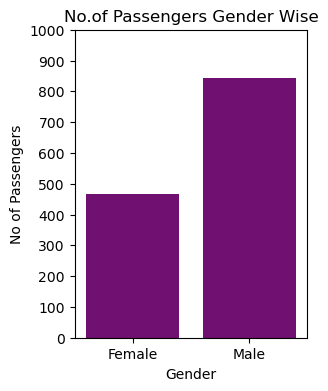

In [55]:
## COUNT PLOT: ( For gender column)
# plot using sns
# customize using matplot


## ticks== ranges


plt.figure(figsize=(3,4)) # width and height
sns.countplot(data=df,x='Gender', color='purple') # color: changes the colour
plt.title("No.of Passengers Gender Wise")

## to change the ranges in y axis
plt.yticks(range(0,1100,100)) ## excludes the stop value


# count name is by default , bcz we are using count plot
# to rename or give new name
plt.ylabel('No of Passengers')



## it ignores the unwantd text and it will show ony the error
plt.show()





## **Observation**

- The dataset contains more male passengers than female passengers.
- Male passengers form the majority of the dataset.
- This information helps us understand the passenger distribution before performing further analysis.

## **Q2: How are passengers distributed across different passenger classes (PClass)?**

**Why ? **

A count plot is used to display the frequency (count) of each category in a categorical column.

Here, Pclass is a categorical feature (Class 1, Class 2, Class 3), so a count plot is the best choice to compare the number of passengers in each class.

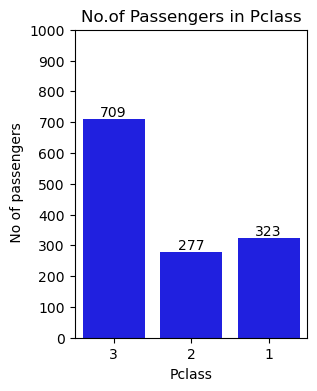

In [56]:
plt.figure(figsize=(3,4)) # width and height

## to display the bar in order wise -->> order[]
cnt=sns.countplot(data=df,x='Pclass', color='blue',order=[3,2,1]) 

## to display the bar label use bar_label func,
#  so 1st store the grapgh in one varriable
cnt.bar_label(cnt.containers[0])


plt.title("No.of Passengers in Pclass")
plt.yticks(range(0,1100,100))
plt.ylabel(" No of passengers")
plt.show()



## **Observation**
- Passenger Class 3 has 709 passengers.
- Passenger Class 1 has 323 passengers.
- Passenger Class 2 has 277 passengers.


Most passengers in the Titanic dataset belonged to Third Class, while Second Class had the fewest passengers. This information helps us understand the passenger distribution and can later be used to analyze whether passenger class affected survival.

## **Q3: How are male and female passengers distributed across different age categories?**

**Why ?**

A count plot is used to display the number of observations in each category.

The hue='Gender' parameter further divides each age category into Male and Female, making it easy to compare both genders within every age group.

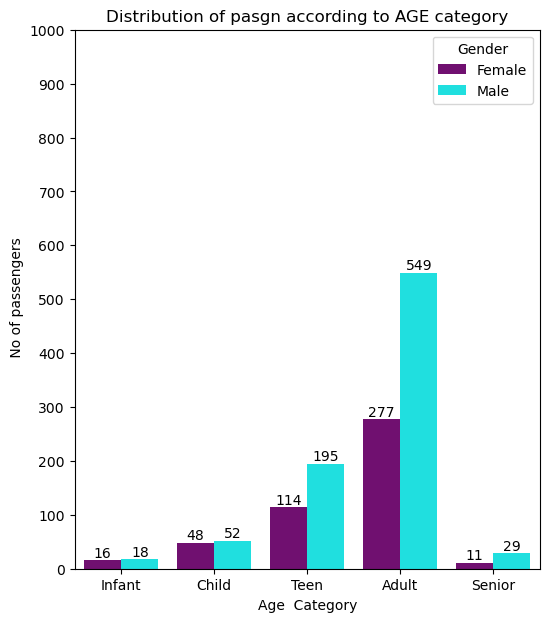

In [57]:
plt.figure(figsize=(6,7)) 

## hue: it is used to place 1 colm inside another
    #  while using hue, we have to give palette=[]
cnt=sns.countplot(data=df,x='Age  Category',hue='Gender', palette=['purple','cyan']) 

## containers0] , 0 bcz  i have 2 column

# cnt.bar_label(cnt.containers[0])
# instaed of writing agin agian use loop
for i in cnt.containers:
    cnt.bar_label(i)
    
plt.title("Distribution of pasgn according to AGE category")
plt.yticks(range(0,1100,100))
plt.ylabel(" No of passengers")
plt.show()



## **Observation:**
- The Adult category has the highest number of passengers.
- Male adults (549) are much more than female adults (277).
- The Teen category has the second-highest number of passengers.
- Very few passengers belong to the Infant and Senior categories.
- In almost every age category, the number of male passengers is higher than female passengers.

The Titanic dataset is dominated by adult passengers, especially adult males. Infants and senior citizens form only a small portion of the passengers. This analysis helps us understand the age and gender distribution before analyzing survival patterns.


## **2. PIE chart** 

to check the percentage, we need to calculate

A pie chart is used to show the percentage or proportion of each category in the dataset.

Unlike a count plot, it helps us understand what percentage of passengers belong to each companion type.

## **Q4: What percentage of passengers traveled Solo, with Family, or with Friends?**

**Step 1: Calculate the frequency of each category**

In [58]:
# Count the number of passengers in each companion type
c = df["Companion_type"].value_counts()

# Display the frequency values
print(c.values)

# Display the category names
print(c.index)

[713 469 127]
Index(['Solo', 'Family', 'Friends'], dtype='object', name='Companion_type')


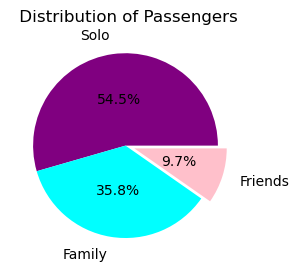

In [ ]:
plt.figure(figsize=(3,3)) # we have to give smae height and width

# to slice the part 
        #use explode [0]means no need , if we increase it will move according to the value
        ## to adjust the percentage number
        ## to adjust the categorical name
        
## x=c.values bcz it takes values and convert into percentage
plt.pie(x=c.values,labels=c.index,autopct='%.1f%%',explode=[0,0,0.1], pctdistance=0.5,labeldistance=1.2,colors=['purple','cyan','pink']) 
# f-> float fromat
# i-> intformat

plt.title(" Distribution of Passengers")

plt.show()

plt.figure(figsize=(3,3))


 ## **OBSERAVTION**

- 54.5% of passengers traveled Solo, making it the largest group.
- 35.8% traveled with Family.
- Only 9.7% traveled with Friends, making it the smallest group.

This analysis shows that most passengers traveled alone (54.5%), followed by those traveling with family (35.8%), while only a small percentage traveled with friends (9.7%).


## **Q5: Which boarding port contributed the highest number of passengers to the Titanic?**

Objective

To analyze the distribution of passengers based on their boarding location and identify which embarkation port had the largest and smallest passenger share.

In [60]:
e=df['Embarked'].value_counts()
e
print(e.values) ## values are the number( frequency or count)
print(e.index)

[916 270 123]
Index(['Southampton', 'Cherbourge', 'Queenstown'], dtype='object', name='Embarked')


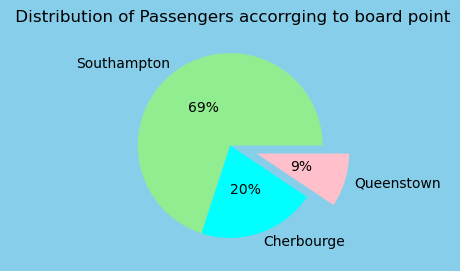

In [61]:
plt.figure(figsize=(3,3), facecolor='skyblue') # we have to give smae height and width
plt.pie(x=e.values,labels=e.index,autopct='%.1i%%',explode=[0,0,0.3], pctdistance=0.5,labeldistance=1.1,colors=['lightgreen','cyan','pink']) 
# f-> float fromat
# i-> intformat


plt.title(" Distribution of Passengers accorrging to board point")

plt.show()


## **Observation**
Most passengers boarded from Southampton (69%).
Cherbourg (20%) had the second-highest number of passengers.
Queenstown (9%) had the fewest passengers.

Southampton was the main boarding port, while Queenstown contributed the least number of passengers. This shows that passenger boarding was concentrated mainly at Southampton.

## **BAR PLOT**

it used for categorical data( always in x axis) and numerical data ( together), to apply aggregrate functions, ( it should not category - category)

-> it can be Univarient / Bivarient

-> if we use 2 colm, it is used to checkk the relation of 2 col  

-> if we use 1 col, it is used to check behaviour

-> by default it always give mean value

  it get other  aggregrate functions  we have to mention it



**Understanding Bar Plot**

A Bar Plot is used to compare a categorical variable with a numerical variable. It summarizes the numerical values using an aggregation function such as mean, sum, count, etc.


## **Q6:  Analyze the total fare paid by male and female passengers to understand how the ticket fare is distributed across different genders.**

In this analysis:

- Category (X-axis): Gender
- Numerical Value (Y-axis): Fare
- Aggregation Used: Sum of Fare

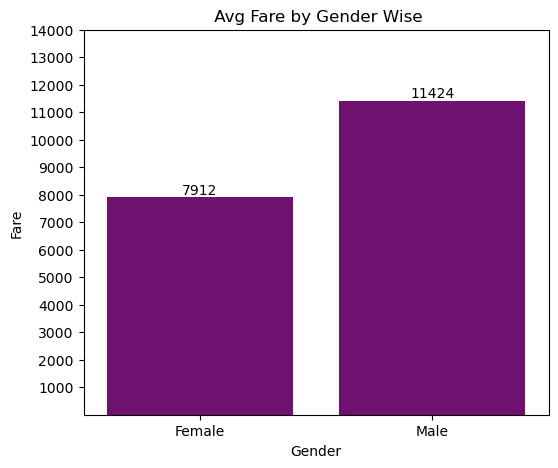

In [62]:
plt.figure(figsize=(6,5))
b=sns.barplot(data =df,x='Gender',y='Fare',errorbar=None,estimator='sum',color='purple')
## while plotting sns we get bar line, that is error bar, to clear use errorbar
b.bar_label(b.containers[0],fmt='%.1i')

plt.yticks(range(1000,15000,1000))
plt.title(" Avg Fare by Gender Wise")
plt.show()

# 

## **Observation**
Male passengers contributed a higher total fare than female passengers.
This may indicate that there were more male passengers or that males collectively paid a higher amount.

💡 Key Note

Since estimator="sum" is used, the graph shows the total fare, not the average fare.

If estimator is not specified, Seaborn uses mean by default.

## **Q7: What is the average ticket fare paid by male and female passengers?**

This bar plot compares the average fare paid by male and female passengers. Since the mean estimator is used, the height of each bar represents the average ticket fare for that gender.

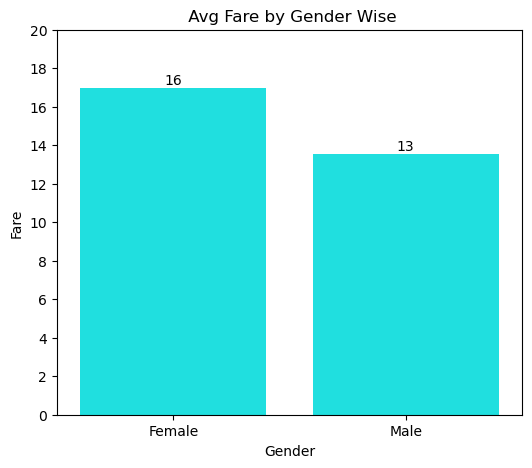

In [63]:
plt.figure(figsize=(6,5))
b=sns.barplot(data =df,x='Gender',y='Fare',errorbar=None,estimator='mean',color='cyan')
## while plotting sns we get bar line, that is error bar, to clear use errorbar
b.bar_label(b.containers[0],fmt='%.1i')

plt.yticks(range(0,22,2))
plt.title(" Avg Fare by Gender Wise")
plt.show()

# 

## **OBSERVATION**

Female passengers paid a higher average fare than male passengers.
The average fare for females is approximately 16, while for males it is around 13.
This suggests that female passengers, on average, purchased costlier tickets than male passengers.


## **Q8: How does the average ticket fare vary across different age categories and genders?**

This bar plot compares the average ticket fare for different age categories (Infant, Child, Teen, Adult, Senior) and separates the comparison by gender. This helps us understand how fare changes with both age and gender.

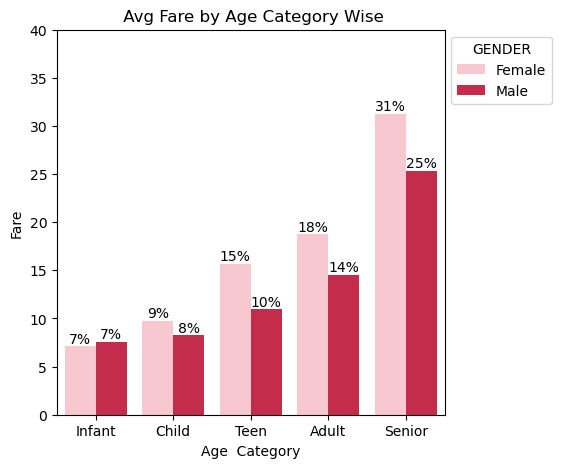

In [64]:
plt.figure(figsize=(5,5))
b=sns.barplot(data =df,x='Age  Category',y='Fare',errorbar=None,estimator='mean',palette=['pink','crimson'],hue='Gender')
## while plotting sns we get bar line, that is error bar, to clear use errorbar

# to naming each box use forloop
for i in b.containers:
    b.bar_label(i,fmt='%.1i%%')
    
    ## to adjust the legends, center, left, left center............
## we can use loc=best. it will fill for the best place
#n col is used-> to place legend name biside each other, orone by one

plt.legend(bbox_to_anchor=(1,1),loc='best',ncol=1,title="GENDER")
    
plt.yticks(range(0,45,5))
plt.title(" Avg Fare by Age Category Wise")
plt.show()

# 

## **OBSERVATION**

The average fare generally increases with age.
Female passengers have a higher average fare than male passengers in most age categories.
Senior females paid the highest average fare among all groups.
Infants have the lowest average fare for both genders.



## **SUBPLOTs**

A subplot is used to display multiple plots in a single figure. It helps compare different aspects of the dataset side by side without creating separate graphs.

Why use Subplots?

- Compare multiple visualizations at the same time.
- Save space and improve readability.
- Make data comparison easier.

## **Q9: Among passengers travelling with their family, what is the distribution of gender and age categories?**

This analysis filters only passengers travelling with their family and displays two pie charts in a single figure:

Gender-wise distribution
Age category-wise distribution

Using subplots makes it easy to compare both distributions at the same time.

In [65]:
## to filter only family

g=df.loc[df['Companion_type']=='Family']
gf=g['Gender'].value_counts()
gn=g['Age  Category'].value_counts()
gf

#3 if we want the percentage distribution, that is pie chart we need value counts

Gender
Female    252
Male      217
Name: count, dtype: int64

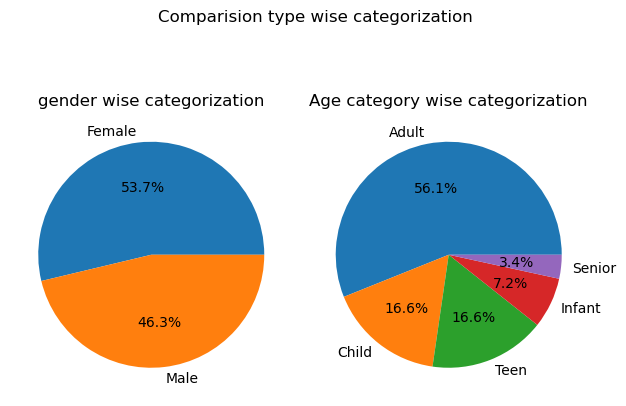

In [66]:
fig,axes=plt.subplots(nrows=1,ncols=2)
plt.suptitle('Comparision type wise categorization')

axes[0].pie(x=gf.values,labels=gf.index, autopct='%.1f%%')
axes[0].set_title("gender wise categorization")


axes[1].pie(x=gn.values,labels=gn.index, autopct='%.1f%%')
axes[1].set_title("Age category wise categorization")

plt.tight_layout()
plt.show()


## **OBSERVATION**

- Female passengers (53.7%) slightly outnumber male passengers (46.3%) among family travellers.
- Adults form the largest age group (56.1%) travelling with family.
- Children and Teens each contribute about 16.6%.
- Infants and Seniors make up the smallest percentage of family travellers.




## **HISTOGRAM** 

---> It is continoues bar(called as bins), attached together, can be used for numerical columns, and also we use kdeplot

---> used for continous range of data, y axis given by defaut (i.e, count)


A Histogram is used to visualize the distribution of a numerical variable. It groups data into continuous intervals called bins and shows how many observations fall within each interval.

Why use a Histogram?

- Understand the distribution of numerical data.
- Identify the most common value range.
- Detect skewness, spread, and possible outliers.

## **Q10:What is the age distribution of passengers in the Titanic dataset?**

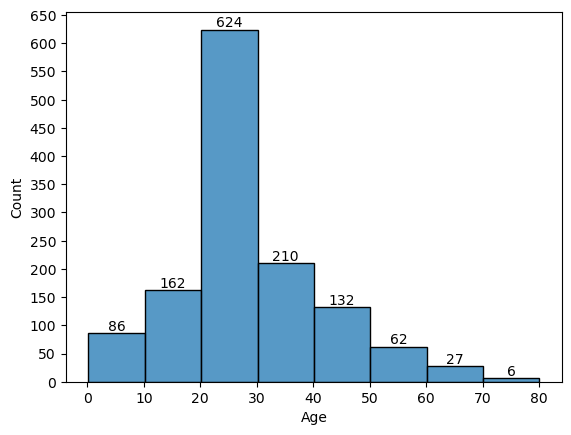

In [67]:
h=sns.histplot(data=df,x='Age',bins=8)
h.bar_label(h.containers[0])
plt.yticks(range(0,700,50))

plt.show()

**OBSERVATION**

- Most passengers are between 20 and 30 years of age.
- The number of passengers decreases as age increases beyond 40 years.
- Very few passengers are above 70 years of age.
- The age distribution is concentrated around young adults.

## **SCATTER PLOT**

That is used to understand the relation btw 2 colm

it is usd in ml for data preprocessing

group formed are called cluster


<Axes: xlabel='Age', ylabel='Fare'>

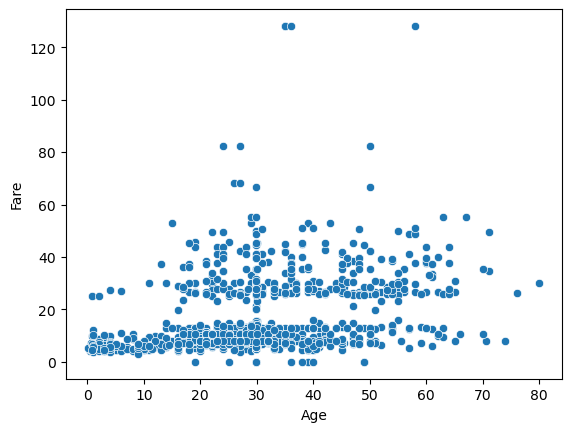

In [68]:
sns.scatterplot(data=df,x='Age',y='Fare')

*OBSERAVTION*

There is no relation between the variables
it helps to understand the patterns



## **CORRELATION**

-> Correlation is used for only numerucal column

-> 

In [ ]:
df.corr(numeric_only=True)*

,Pclass,Sibsp,Parch,Age,Fare,Fam_count,No_of_Passengers,Survived
Pclass,1.000000,0.060832,0.018322,-0.366242,-0.769482,0.050027,-0.078554,-0.312469
Sibsp,0.060832,1.000000,0.373587,-0.190739,-0.051361,0.861952,0.679444,-0.027825
Parch,0.018322,0.373587,1.000000,-0.130924,-0.030942,0.792296,0.647029,0.082660
Age,-0.366242,-0.190739,-0.130924,1.000000,0.339854,-0.197019,-0.155093,-0.050262
Fare,-0.769482,-0.051361,-0.030942,0.339854,1.000000,-0.050695,0.093484,0.264726
Fam_count,0.050027,0.861952,0.792296,-0.197019,-0.050695,1.000000,0.800556,0.026876
No_of_Passengers,-0.078554,0.679444,0.647029,-0.155093,0.093484,0.800556,1.000000,0.075293
Survived,-0.312469,-0.027825,0.082660,-0.050262,0.264726,0.026876,0.075293,1.000000


## **HEATMAP**

it will visualize throughthe colours

**Anot=True**-> to display the numbers in the heatmap

<Axes: >

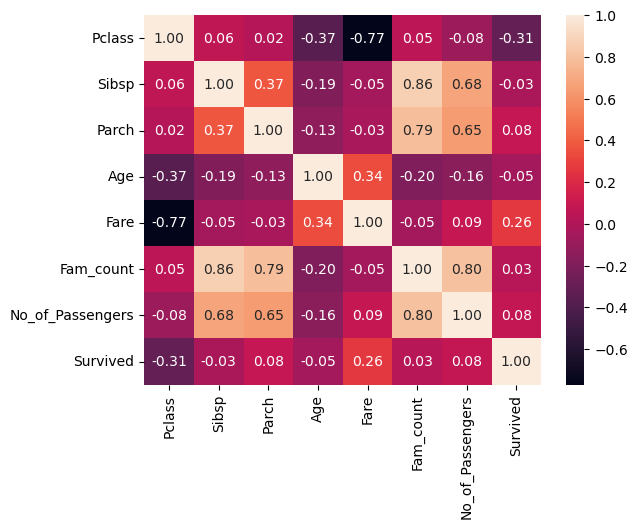

In [70]:
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt='.2f')


## **FACETGRID**

-> to visualize the data based on the category


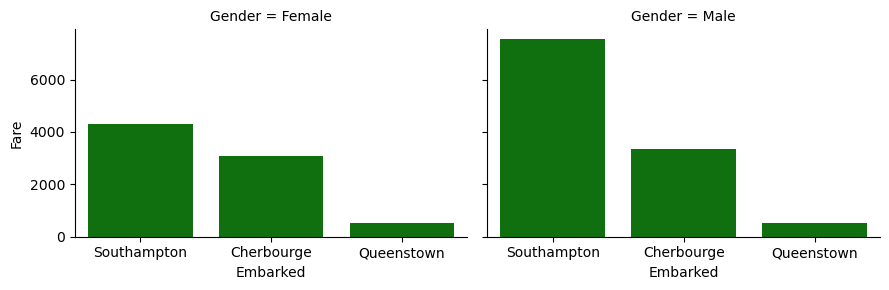

In [71]:
# to visualize total fare paid by female and male at each boarding point

## to fing sum we can use bar plot

## insside which data to be passed are decided by map

fc=sns.FacetGrid(df,col='Gender',aspect=1.5)

fc.map_dataframe(sns.barplot,x='Embarked',y='Fare',estimator='sum',errorbar=None,color='green')


plt.show()
